# Regression

## Model Representation

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
x_train = np.array([1.0, 2.0])
y_train = np.array([300.0, 500.0])

print(f"x_train = {x_train}")
print(f"y_train = {y_train}")

x_train = [1. 2.]
y_train = [300. 500.]


In [3]:
print(f"x_train.shape = {x_train.shape}")
# m is no. of training examples
m = x_train.shape[0]
print(f"Number of training examples is: {m}")

# or
m = len(x_train)
print(f"Number of training examples is: {m}")

x_train.shape = (2,)
Number of training examples is: 2
Number of training examples is: 2


In [4]:
# Training examples x_i, y_i denote the  𝑖𝑡ℎ training example
i = 0
x_i = x_train[i]
y_i = y_train[i]
print(f"(x^{i}, y^{i}) = ({x_i}, {y_i})")

(x^0, y^0) = (1.0, 300.0)


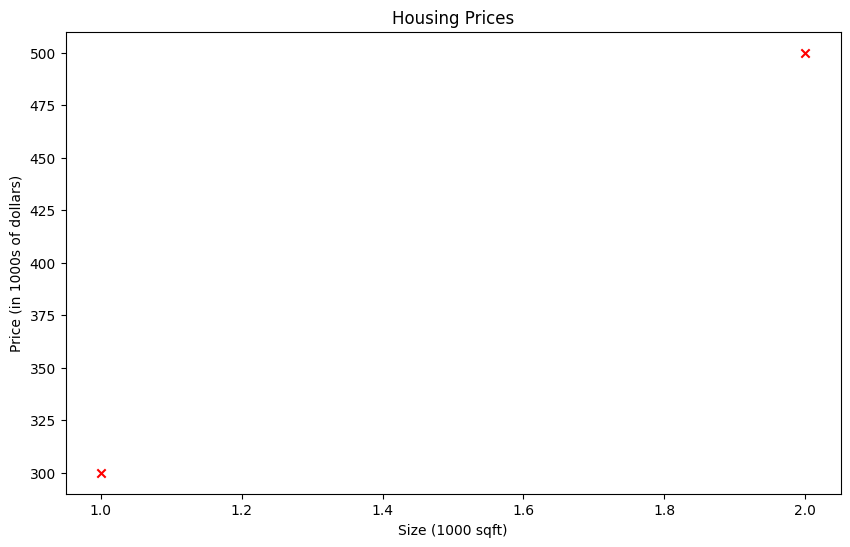

In [5]:
plt.figure(figsize=(10, 6))
# Plotting the data
plt.scatter(x_train, y_train, marker='x', c='r')
# scatter function is to plot scatter plots
# it is used to see relationship between two features(first 2 parmeters are these features)
# marker parameter controls shape of data points
# c parameter is for color of data points.
plt.title("Housing Prices")
plt.ylabel("Price (in 1000s of dollars)")
plt.xlabel("Size (1000 sqft)")
plt.show()

### Model Function

In [6]:
def compute_model_output(x,w,b):
    m = x.shape[0]
    f_wb = np.zeros(m)
    # zeros(shape) is a NumPy function that creates an array filled with zeros
    # shape defines the size (or dimensions) of the array
    
    for i in range(m):
        f_wb[i] = w*x[i] + b

    return f_wb

<function matplotlib.pyplot.show(close=None, block=None)>

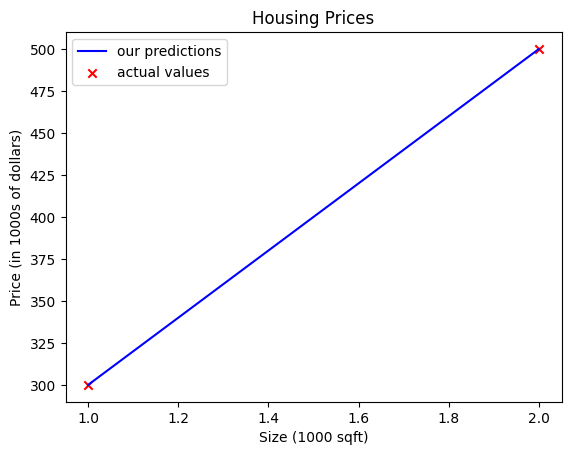

In [7]:
temp_f_wb = compute_model_output(x_train, 200, 100)

plt.plot(x_train, temp_f_wb, c='b', label='our predictions')
# plot() is for lineplot take x,y as data parameters
plt.scatter(x_train, y_train, marker='x', c='r', label='actual values')
plt.title('Housing Prices')
plt.ylabel('Price (in 1000s of dollars)')
plt.xlabel('Size (1000 sqft)')
plt.legend()
plt.show

### Prediction

In [8]:
w = 200
b = 100
x_i = 1.2
cost_1200sqft = w * x_i + b
print(f"${cost_1200sqft:.0f} thousand dollas")
# ':.nf' is a format specifier and n is no. of digits to be shown after decimal

$340 thousand dollas


## Cost Function
- cost function for linear regression with one variable.

In [9]:
x_train = np.array([1.0, 2.0])
y_train = np.array([300.0, 500.0])

### Computing cost
- here, cost is a measure how well our regression model is predicting the target price of the house.
- equation for cost with one variable:

  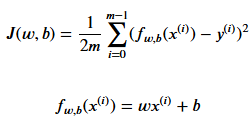

In [10]:
def compute_cost(x, y, w, b):
    m = x.shape[0]

    count_sum = 0
    for i in range(m):
        f_wb = w * x[i] + b
    return ((f_wb - y[i])**2)/(2*m)

In [11]:
def best_w(x, y, b):
    min_score = float('inf')
    w = None
    for i in range(0, 1001, 50):
        score = compute_cost(x, y, i, b)
        if (score < min_score):
            min_score = score
            w = i
    return w

In [12]:
print(best_w(x_train, y_train, 100))

200


## Gradient Descent for Linear Regression

In [13]:
import math, copy

In [14]:
x_train = np.array([1.0, 2.0])
y_train = np.array([300.0, 500.0])

In [15]:
def compute_cost(x,y,w,b):
    m = x.shape[0]
    cost = 0

    for i in range(m):
        f_wb = w*x[i] + b
        cost = cost + (f_wb - y[i])**2

    total_cost = (cost)/(2*m)

    return total_cost

### Implement Gradient Descent

#### Compute Gradient

In [16]:
def compute_gradient(x,y,w,b):
    m = x.shape[0]
    dj_dw = 0
    db_dw = 0

    for i in range(m):
        f_wb = w * x[i] + b

        dj_dw_i = (f_wb - y[i]) * x[i]
        db_dw_i = f_wb - y[i]

        dj_dw += dj_dw_i
        db_dw += db_dw_i
    
    dj_dw = dj_dw/m
    db_dw = db_dw/m

    return dj_dw, db_dw

#### Gradient Descent

In [17]:
def gradient_descent(x, y, w_in, b_in, alpha, num_iters, cost_function, gradient_function):
# function are first class object so they can be passed as arguments in a different function
    j_history = []
    p_history = []
    
    w = w_in
    b = b_in

    for i in range(num_iters):
        dj_dw, dj_db = gradient_function(x, y, w, b)
        w = w - alpha*dj_dw
        b = b - alpha*dj_db

        if i < 100000: # i < 100000 is a safety cap
            j_history.append(cost_function(x, y, w, b))
            p_history.append([w, b])
        
        if i % math.ceil(num_iters/10) == 0: # it will execute 10 times
            print(f"Iteration {i:4}: cost {j_history[-1]:0.2e}", # {i:n} this will reserve n no. of character space if no. of characters of i is < n.
                  f"dj_dw: {dj_dw: 0.3e}, dj_db: {dj_db: 0.3e}",
                  f"w: {w: 0.3e}, b: {b: 0.5e}") # {v:0.ne} print for powers of 10 and space before 0 is for alignment of -ve and +ve values
    return w, b, j_history, p_history

In [18]:
w_init = 0
b_init = 0
iterations = 10000
tmp_alpha = 1.0e-2

w_final, b_final, j_hist, p_hist = gradient_descent(x_train, y_train, w_init, b_init, tmp_alpha,
                                                    iterations, compute_cost, compute_gradient)
print(f"(w,b) found by gradient descent: ({w_final:8.4f}, {b_final:8.4f})")
# {val:m.nf} means print m characters wide and keep n digits after decimal

Iteration    0: cost 7.93e+04 dj_dw: -6.500e+02, dj_db: -4.000e+02 w:  6.500e+00, b:  4.00000e+00
Iteration 1000: cost 3.41e+00 dj_dw: -3.712e-01, dj_db:  6.007e-01 w:  1.949e+02, b:  1.08228e+02
Iteration 2000: cost 7.93e-01 dj_dw: -1.789e-01, dj_db:  2.895e-01 w:  1.975e+02, b:  1.03966e+02
Iteration 3000: cost 1.84e-01 dj_dw: -8.625e-02, dj_db:  1.396e-01 w:  1.988e+02, b:  1.01912e+02
Iteration 4000: cost 4.28e-02 dj_dw: -4.158e-02, dj_db:  6.727e-02 w:  1.994e+02, b:  1.00922e+02
Iteration 5000: cost 9.95e-03 dj_dw: -2.004e-02, dj_db:  3.243e-02 w:  1.997e+02, b:  1.00444e+02
Iteration 6000: cost 2.31e-03 dj_dw: -9.660e-03, dj_db:  1.563e-02 w:  1.999e+02, b:  1.00214e+02
Iteration 7000: cost 5.37e-04 dj_dw: -4.657e-03, dj_db:  7.535e-03 w:  1.999e+02, b:  1.00103e+02
Iteration 8000: cost 1.25e-04 dj_dw: -2.245e-03, dj_db:  3.632e-03 w:  2.000e+02, b:  1.00050e+02
Iteration 9000: cost 2.90e-05 dj_dw: -1.082e-03, dj_db:  1.751e-03 w:  2.000e+02, b:  1.00024e+02
(w,b) found by gradi

### Cost versus iterations of gradient descent

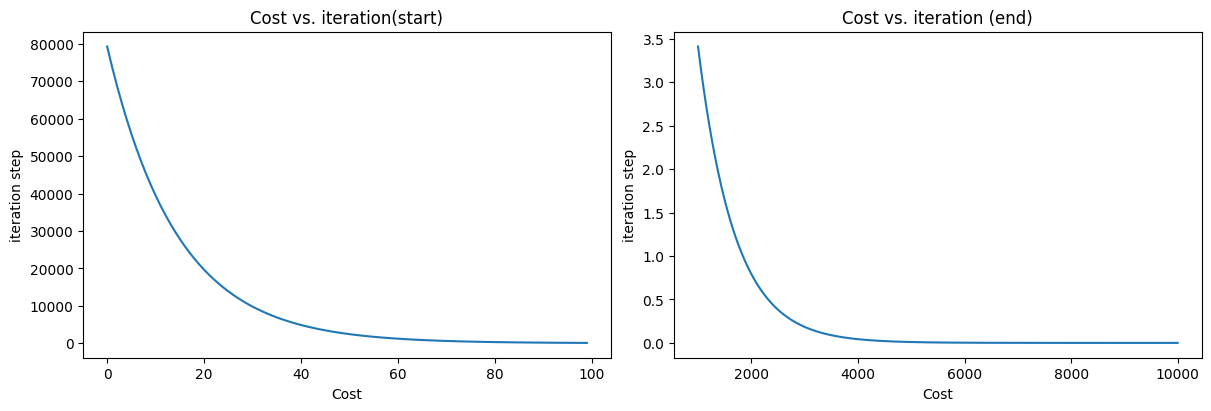

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, constrained_layout=True, figsize=(12,4))
# creating blank canvas for 2 plots
# fig is an figure object
# ax1,ax2 are Axes object
ax1.plot(j_hist[:100])
ax2.plot(1000 + np.arange(len(j_hist[1000:])), j_hist[1000:])
# np.arange() is like python's range() function but it creates an array

ax1.set_title("Cost vs. iteration(start)")
ax2.set_title("Cost vs. iteration (end)")

ax1.set_xlabel("Cost")
ax2.set_xlabel("Cost")

ax1.set_ylabel("iteration step")
ax2.set_ylabel("iteration step")
# use set_ before every plt function as we are using them on Axes object

plt.show()



### Predictions

In [25]:
print(f"1000 sqft house prediction {w_final*1.0 + b_final:0.1f} Thousand Dollars")
print(f"1200 sqft house prediction {w_final*1.2 + b_final:0.1f} Thoudand Dollars")
print(f"2000 sqft house prediction {w_final*2.0 + b_final:0.1f} Thousand Dollars")

1000 sqft house prediction 300.0 Thousand Dollars
1200 sqft house prediction 340.0 Thoudand Dollars
2000 sqft house prediction 500.0 Thousand Dollars


### Increased Learing Rate

In [27]:
w_init = 0
b_init = 0

iterations = 10
tmp_alpha = 8.0e-1

w_final, b_final, j_hist, p_hist = gradient_descent(x_train, y_train, w_init, b_init, tmp_alpha,
                                                    iterations, compute_cost, compute_gradient)

Iteration    0: cost 2.58e+05 dj_dw: -6.500e+02, dj_db: -4.000e+02 w:  5.200e+02, b:  3.20000e+02
Iteration    1: cost 7.82e+05 dj_dw:  1.130e+03, dj_db:  7.000e+02 w: -3.840e+02, b: -2.40000e+02
Iteration    2: cost 2.37e+06 dj_dw: -1.970e+03, dj_db: -1.216e+03 w:  1.192e+03, b:  7.32800e+02
Iteration    3: cost 7.19e+06 dj_dw:  3.429e+03, dj_db:  2.121e+03 w: -1.551e+03, b: -9.63840e+02
Iteration    4: cost 2.18e+07 dj_dw: -5.974e+03, dj_db: -3.691e+03 w:  3.228e+03, b:  1.98886e+03
Iteration    5: cost 6.62e+07 dj_dw:  1.040e+04, dj_db:  6.431e+03 w: -5.095e+03, b: -3.15579e+03
Iteration    6: cost 2.01e+08 dj_dw: -1.812e+04, dj_db: -1.120e+04 w:  9.402e+03, b:  5.80237e+03
Iteration    7: cost 6.09e+08 dj_dw:  3.156e+04, dj_db:  1.950e+04 w: -1.584e+04, b: -9.80139e+03
Iteration    8: cost 1.85e+09 dj_dw: -5.496e+04, dj_db: -3.397e+04 w:  2.813e+04, b:  1.73730e+04
Iteration    9: cost 5.60e+09 dj_dw:  9.572e+04, dj_db:  5.916e+04 w: -4.845e+04, b: -2.99567e+04
